Warning message:
“One or more parsing issues, call `problems()` on your data frame for details,
e.g.:
  dat <- vroom(...)
  problems(dat)”
Rows: 19435 Columns: 112
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (64): RCONSC, SEX, RSLEEP, RATRIAL, RCT, RVISINF, RHEP24, RASP3, RDEF1, ...
dbl (48): HOSPNUM, RDELAY, AGE, RSBP, HOURLOCAL, MINLOCAL, DAYLOCAL, ONDRUG,...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


[1] "\n\nCleaner version without confidence bands:"


`geom_smooth()` using formula = 'y ~ x'


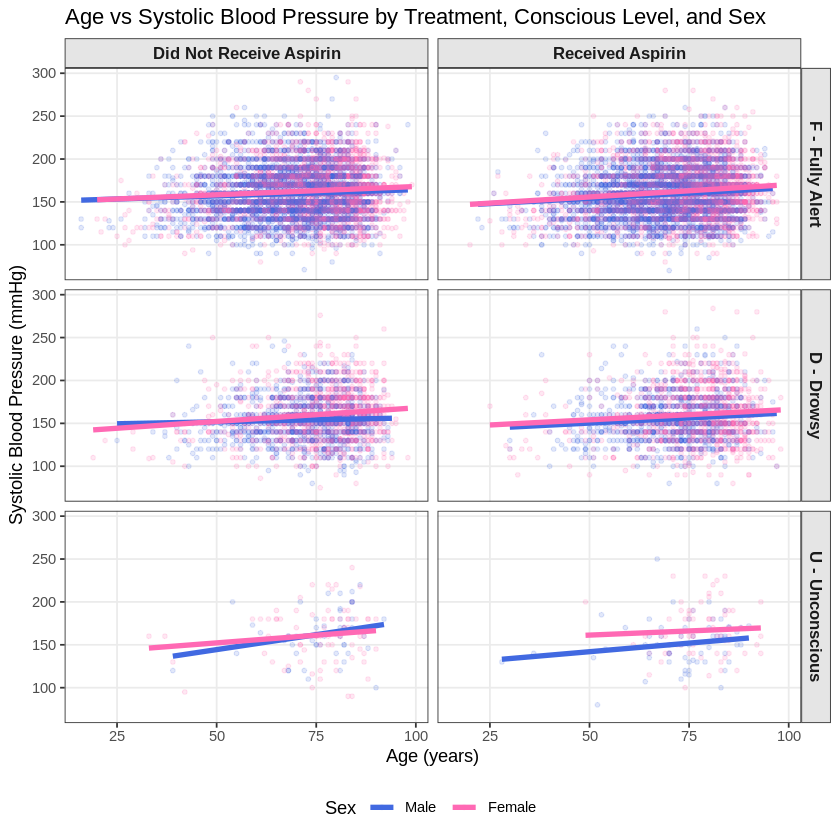

In [ ]:
# Age vs Systolic BP by Aspirin Treatment, Conscious Level, and Sex

library(tidyverse)
library(ggplot2)

# Read the data
IST_data <- read_csv("IST-data.CSV")

# Prepare data with proper labels
grid_data <- IST_data %>%
  filter(!is.na(AGE) & !is.na(RSBP) & !is.na(RXASP) & !is.na(RCONSC) & !is.na(SEX)) %>%
  mutate(
    aspirin_group = factor(RXASP,
                          levels = c("N", "Y"),
                          labels = c("Did Not Receive Aspirin", "Received Aspirin")),
    conscious_level = factor(RCONSC,
                            levels = c("F", "D", "U"),
                            labels = c("F - Fully Alert", "D - Drowsy", "U - Unconscious")),
    sex = factor(SEX,
                levels = c("M", "F"),
                labels = c("Male", "Female"))
  )


p_clean <- ggplot(grid_data, aes(x = AGE, y = RSBP, color = sex)) +
  geom_point(alpha = 0.15, size = 1) +
  geom_smooth(method = "lm", se = FALSE, linewidth = 1.5) +
  facet_grid(conscious_level ~ aspirin_group) +
  scale_color_manual(values = c("Male" = "#4169E1", "Female" = "#FF69B4"),
                     name = "Sex") +
  labs(title = "Age vs Systolic Blood Pressure by Treatment, Conscious Level, and Sex",
       x = "Age (years)",
       y = "Systolic Blood Pressure (mmHg)") +
  theme_bw() +
  theme(
    legend.position = "bottom",
    strip.text = element_text(size = 10, face = "bold"),
    strip.background = element_rect(fill = "grey90"),
    panel.grid.minor = element_blank()
  )

print("\n\nCleaner version without confidence bands:")
print(p_clean)

In [ ]:
library(dplyr)
library(readr)
data <- read_csv("IST-data.CSV")

# Keep only known outcomes and relevant columns
data_clean <- data %>%
  filter(FDEAD %in% c("Y", "N")) %>%  # exclude unknowns
  mutate(
    death6mo = ifelse(FDEAD == "Y", 1, 0),
    month = RDATE,       # Month of randomisation (yyyy-mm)
    country = COUNTRY,   # Country code
    age = AGE            # Age in years
  )
death_summary <- data_clean %>%
  group_by(month, age, country) %>%
  summarise(
    n_total = n(),
    n_deaths = sum(death6mo),
    prop_deaths = n_deaths / n_total
  ) %>%
  ungroup()
death_summary <- data_clean %>%
  group_by(month, age, country) %>%
  summarise(
    n_total = n(),
    n_deaths = sum(death6mo),
    prop_deaths = n_deaths / n_total
  ) %>%
  ungroup()
head(death_summary)



Warning message:
“One or more parsing issues, call `problems()` on your data frame for details,
e.g.:
  dat <- vroom(...)
  problems(dat)”
Rows: 19435 Columns: 112
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (64): RCONSC, SEX, RSLEEP, RATRIAL, RCT, RVISINF, RHEP24, RASP3, RDEF1, ...
dbl (48): HOSPNUM, RDELAY, AGE, RSBP, HOURLOCAL, MINLOCAL, DAYLOCAL, ONDRUG,...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
`summarise()` has grouped output by 'month', 'age'. You can override using the
`.groups` argument.
`summarise()` has grouped output by 'month', 'age'. You can override using the
`.groups` argument.


month,age,country,n_total,n_deaths,prop_deaths
<chr>,<dbl>,<chr>,<int>,<dbl>,<dbl>
1991-01,69,UK,1,0,0
1991-01,71,UK,1,0,0
1991-01,76,UK,1,0,0
1991-01,81,UK,1,0,0
1991-02,23,UK,1,0,0
1991-02,47,UK,1,0,0


Warning message:
“One or more parsing issues, call `problems()` on your data frame for details,
e.g.:
  dat <- vroom(...)
  problems(dat)”
Rows: 19435 Columns: 112
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (64): RCONSC, SEX, RSLEEP, RATRIAL, RCT, RVISINF, RHEP24, RASP3, RDEF1, ...
dbl (48): HOSPNUM, RDELAY, AGE, RSBP, HOURLOCAL, MINLOCAL, DAYLOCAL, ONDRUG,...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
`summarise()` has grouped output by 'month', 'age'. You can override using the
`.groups` argument.
`summarise()` has grouped output by 'age'. You can override using the `.groups`
argument.
`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 415 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 415 rows containing missing values or values outside the scale range


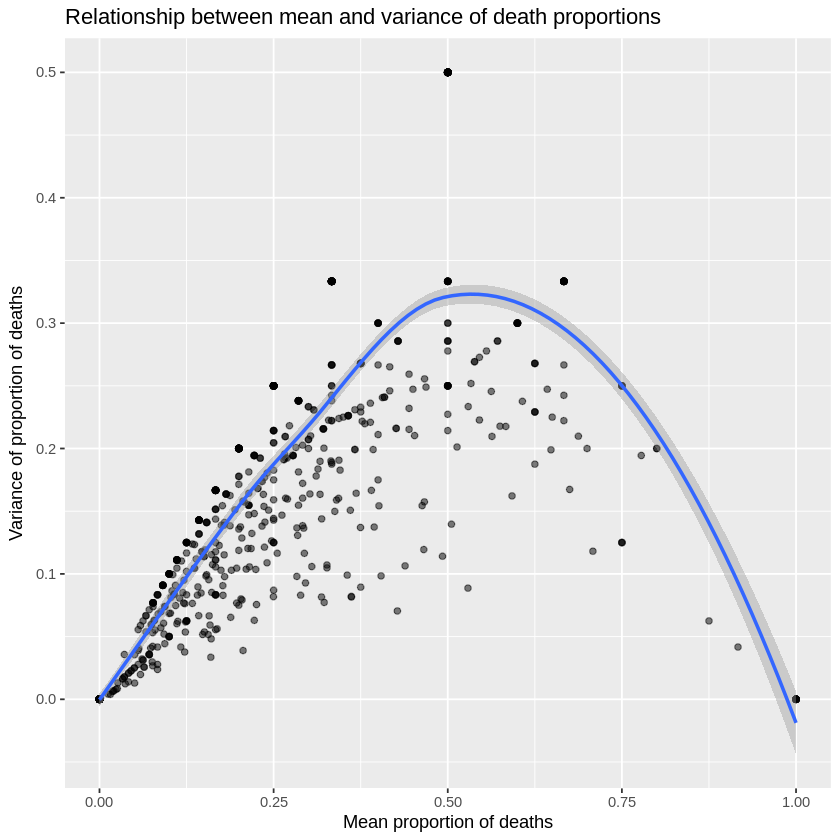

In [ ]:
library(dplyr)
library(readr)

# Read data
data <- read_csv("IST-data.CSV")

# Clean and recode
data_clean <- data %>%
  filter(FDEAD %in% c("Y","N")) %>%
  mutate(
    death6mo = ifelse(FDEAD == "Y", 1, 0),
    month = RDATE,
    age = AGE,
    country = COUNTRY
  )

# Compute death proportions per month-age-country
death_props <- data_clean %>%
  group_by(month, age, country) %>%
  summarise(
    n_total = n(),
    n_deaths = sum(death6mo),
    prop_deaths = n_deaths / n_total
  ) %>%
  ungroup()
summary_stats <- death_props %>%
  group_by(age, country) %>%
  summarise(
    mean_prop = mean(prop_deaths),
    var_prop = var(prop_deaths),
    n_months = n()
  ) %>%
  ungroup()
library(ggplot2)

ggplot(summary_stats, aes(x = mean_prop, y = var_prop)) +
  geom_point(alpha = 0.5) +
  geom_smooth(method = "loess") +
  labs(x = "Mean proportion of deaths",
       y = "Variance of proportion of deaths",
       title = "Relationship between mean and variance of death proportions")
